In [ ]:
# Import All Libraries 
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              f1_score, precision_score, recall_score)

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print("All libraries imported successfully.")

All libraries imported successfully.


In [4]:
import pandas as pd

# Correct paths
MOVIES_PATH  = r"C:\Users\visma\Downloads\movie\tmdb_5000_movies.csv"
CREDITS_PATH = r"C:\Users\visma\Downloads\movie\tmdb_5000_credits.csv"

# Load datasets
movies  = pd.read_csv(MOVIES_PATH)
credits = pd.read_csv(CREDITS_PATH)

# Fix column name for merging
credits = credits.rename(columns={'movie_id': 'id'})

# Merge datasets
movies = movies.merge(credits[['id', 'cast', 'crew']], on='id', how='left')

print(f"✓ Merged dataset shape: {movies.shape}")

movies.head()

✓ Merged dataset shape: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
# Dataset Overview 
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Total movies (rows)  : {len(movies)}")
print(f"Total columns        : {len(movies.columns)}")
print()
print("Column Data Types:")
print(movies.dtypes.to_string())
print()
print("Basic Statistics (numerical columns):")
movies[['budget', 'revenue', 'vote_average', 'vote_count', 'popularity', 'runtime']].describe().round(2)

DATASET OVERVIEW
Total movies (rows)  : 4803
Total columns        : 22

Column Data Types:
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object

Basic Statistics (numerical columns):


,budget,revenue,vote_average,vote_count,popularity,runtime
count,4.803000e+03,4.803000e+03,4803.00,4803.00,4803.00,4801.00
mean,2.904504e+07,8.226064e+07,6.09,690.22,21.49,106.88
std,4.072239e+07,1.628571e+08,1.19,1234.59,31.82,22.61
min,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00
25%,7.900000e+05,0.000000e+00,5.60,54.00,4.67,94.00
50%,1.500000e+07,1.917000e+07,6.20,235.00,12.92,103.00
75%,4.000000e+07,9.291719e+07,6.80,737.00,28.31,118.00
max,3.800000e+08,2.787965e+09,10.00,13752.00,875.58,338.00


# Data Cleaning and Missing Value Handling

Missing Values Per Column:
                      Missing Count  Missing %
budget                            0       0.00
genres                            0       0.00
homepage                       3091      64.36
id                                0       0.00
keywords                          0       0.00
original_language                 0       0.00
original_title                    0       0.00
overview                          3       0.06
popularity                        0       0.00
production_companies              0       0.00
production_countries              0       0.00
release_date                      1       0.02
revenue                           0       0.00
runtime                           2       0.04
spoken_languages                  0       0.00
status                            0       0.00
tagline                         844      17.57
title                             0       0.00
vote_average                      0       0.00
vote_count                       

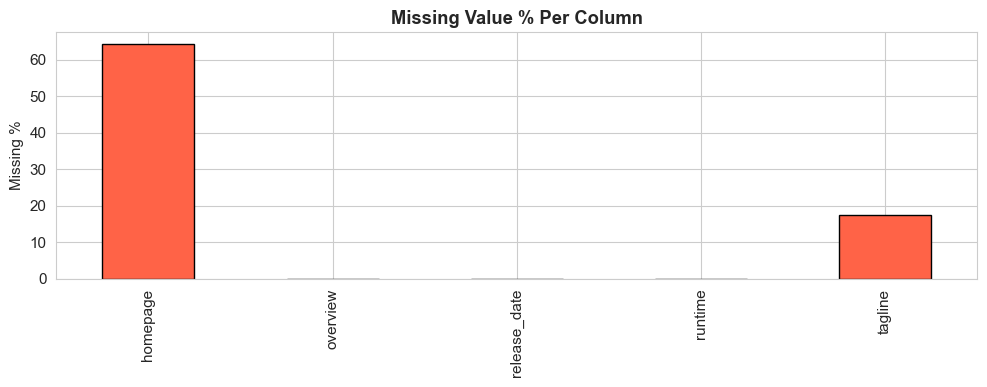

In [ ]:
# Check Missing Values 
missing     = movies.isnull().sum()
missing_pct = (missing / len(movies) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print("Missing Values Per Column:")
print(missing_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
has_missing = missing_pct[missing_pct > 0]
if len(has_missing) > 0:
    has_missing.plot(kind='bar', ax=ax, color='tomato', edgecolor='black')
    ax.set_title('Missing Value % Per Column', fontweight='bold')
    ax.set_ylabel('Missing %')
else:
    ax.text(0.5, 0.5, 'No Missing Values Found ✓',
            ha='center', va='center', fontsize=14, transform=ax.transAxes,
            color='green', fontweight='bold')
    ax.set_title('Missing Value Check', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

# Replace 0 with NaN
movies['budget'] = movies['budget'].replace(0, np.nan)
movies['revenue'] = movies['revenue'].replace(0, np.nan)
movies['runtime'] = movies['runtime'].replace(0, np.nan)

before = len(movies)

# Drop rows with missing critical values
movies = movies.dropna(subset=['budget', 'revenue', 'vote_average', 'vote_count', 'popularity'])

# Fill runtime with median
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())

# Remove duplicates
movies = movies.drop_duplicates()
movies = movies.reset_index(drop=True)

removed = before - len(movies)

print(f"Removed {removed} rows with missing/zero budget or revenue.")
print(f"Final clean dataset: {len(movies)} movies")

print("Missing values after cleaning:")
print(movies[['budget','revenue','vote_average','vote_count','popularity','runtime']].isnull().sum())

print("No missing values remain" if movies.isnull().sum().sum() == 0 else "Some NaNs remain — check above.")

Removed 1574 rows with missing/zero budget or revenue.
Final clean dataset: 3229 movies
Missing values after cleaning:
budget          0
revenue         0
vote_average    0
vote_count      0
popularity      0
runtime         0
dtype: int64
Some NaNs remain — check above.


### Observation — Missing Values & Cleaning

The dataset initially contained missing values, most notably in the homepage (64.36%) and tagline (17.57%) columns, which are not critical for predicting movie success. Core features such as budget, revenue, vote_average, vote_count, and popularity had no missing values but contained invalid zeros in some cases.

These zeros were treated as missing values and handled appropriately. Rows with missing or zero budget and revenue were removed, as they are essential for computing financial performance. The runtime column had a few missing values, which were imputed using the median.

After cleaning, the dataset was reduced from its original size to 3229 movies, ensuring that all key features are complete and suitable for model training.

#  Outlier Detection and Treatment

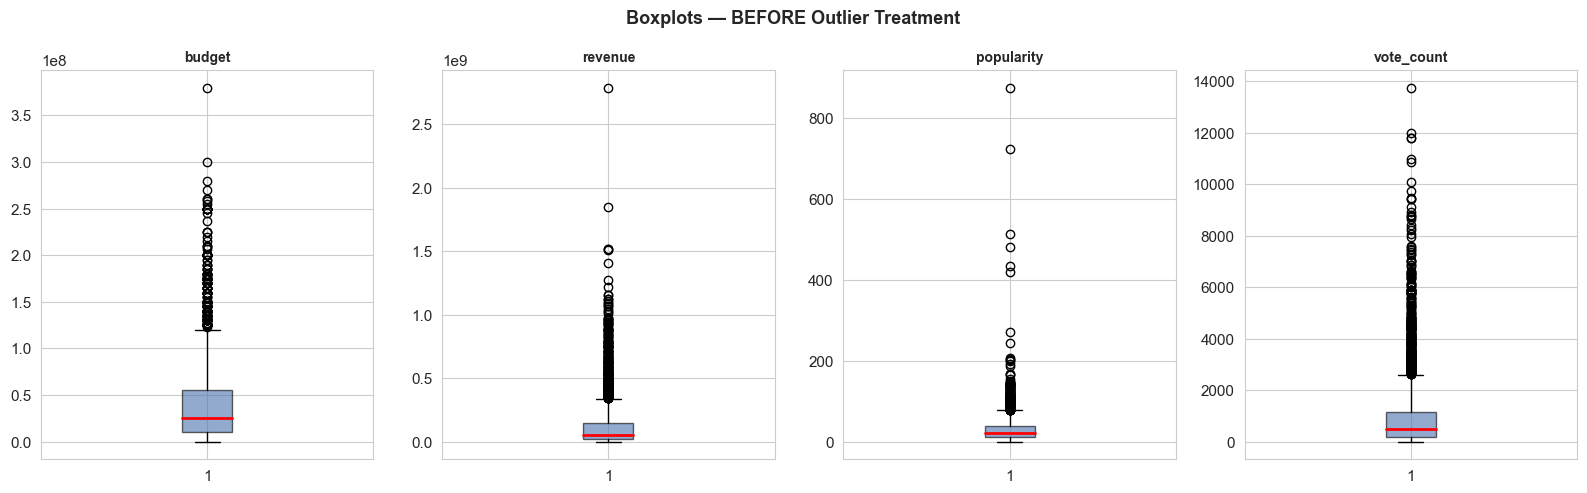

In [ ]:
# Boxplots BEFORE Outlier Treatment
num_cols = ['budget', 'revenue', 'popularity', 'vote_count']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(movies[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#4C72B0', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10, fontweight='bold')
fig.suptitle('Boxplots — BEFORE Outlier Treatment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The boxplots show strong right-skew with many extreme outliers in budget, revenue, popularity, and vote_count. A few blockbuster movies dominate the upper range, which can distort model training, so outlier treatment is required.

In [ ]:
# Apply IQR Capping
def winsorise(df, col, factor=1.5):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col:22s} → {n_outliers:4d} outlier(s) capped  "
          f"[lower={lower:.2f}, upper={upper:.2f}]")
    return df

winsorise_cols = ['budget', 'revenue', 'popularity', 'vote_count', 'runtime']
print("Outlier Treatment (IQR × 1.5 capping):")
for col in winsorise_cols:
    movies = winsorise(movies, col)

print("Outlier treatment complete.")

Outlier Treatment (IQR × 1.5 capping):
  budget                 →  216 outlier(s) capped  [lower=-56250000.00, upper=121750000.00]
  revenue                →  285 outlier(s) capped  [lower=-176938013.50, upper=340230022.50]
  popularity             →  175 outlier(s) capped  [lower=-29.89, upper=77.67]
  vote_count             →  305 outlier(s) capped  [lower=-1277.00, upper=2603.00]
  runtime                →   99 outlier(s) capped  [lower=58.50, upper=158.50]
Outlier treatment complete.


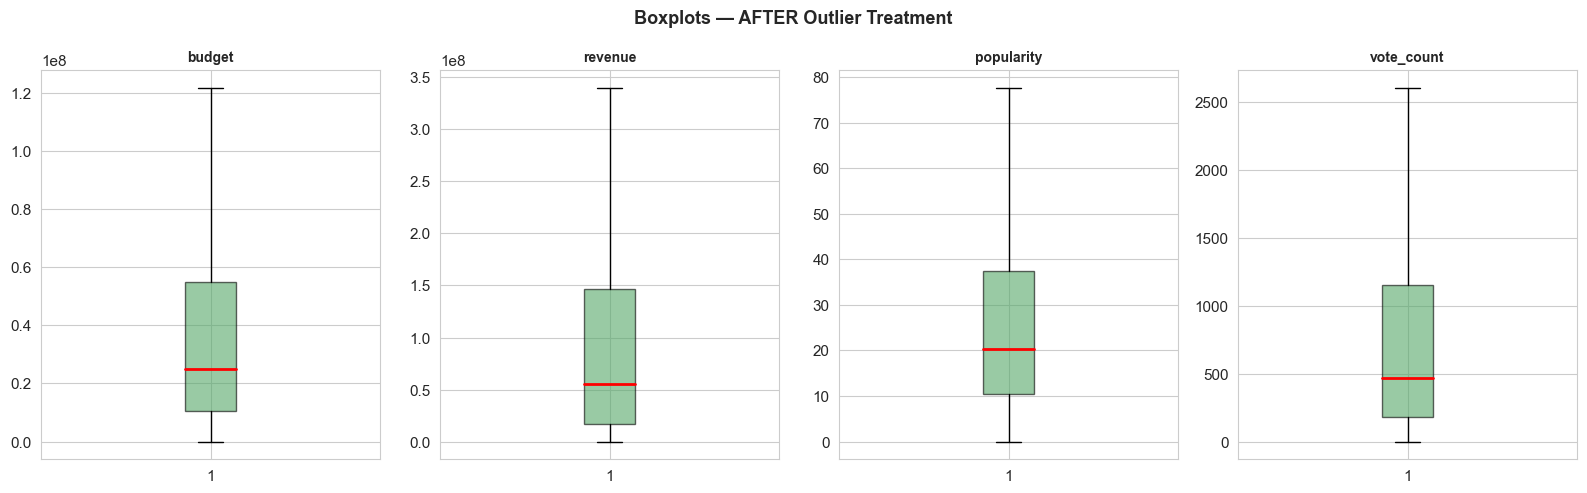

Outliers are now under control.


In [ ]:
# Boxplots AFTER Outlier Treatment
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(movies[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#55A868', alpha=0.6),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10, fontweight='bold')
fig.suptitle('Boxplots — AFTER Outlier Treatment', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("Outliers are now under control.")

### Observation:
After applying IQR capping, extreme outliers are significantly reduced and the distributions are more compact. The data is now less skewed, making it more suitable for stable and reliable model training.

## Feature Engineering

In [ ]:
# Parse Genre and Extract Release Month
import ast

def extract_primary_genre(genres_str):
    """Extract first genre name from JSON-like genres column."""
    try:
        genres_list = ast.literal_eval(genres_str)
        if genres_list:
            return genres_list[0]['name']
        return 'Unknown'
    except:
        return 'Unknown'

def count_genres(genres_str):
    try:
        return len(ast.literal_eval(genres_str))
    except:
        return 0

# Apply genre parsing (adjust column name if yours differs)
genre_col = 'genres'   # ← update if your column is named differently
if genre_col in movies.columns:
    movies['primary_genre'] = movies[genre_col].apply(extract_primary_genre)
    movies['num_genres']    = movies[genre_col].apply(count_genres)
else:
    movies['primary_genre'] = 'Unknown'
    movies['num_genres']    = 1

# Release month
if 'release_date' in movies.columns:
    movies['release_date']  = pd.to_datetime(movies['release_date'], errors='coerce')
    movies['release_month'] = movies['release_date'].dt.month.fillna(6).astype(int)
else:
    movies['release_month'] = 6

print("Primary genre sample:")
print(movies['primary_genre'].value_counts().head(10).to_string())
print(f"\nNum genres range: {movies['num_genres'].min()} – {movies['num_genres'].max()}")

Primary genre sample:
primary_genre
Drama              747
Comedy             634
Action             588
Adventure          288
Horror             197
Crime              141
Thriller           118
Animation           99
Fantasy             93
Science Fiction     79

Num genres range: 0 – 7


### Observation:
Genre parsing successfully extracted the primary genre and number of genres per movie. Most movies belong to Drama and Comedy, and the number of genres ranges from 0 to 7, providing useful categorical and diversity features for the model.

In [ ]:
# Create Financial and Audience Features 
eps = 1e-6  # avoid division by zero

# Financial features
movies['profit'] = movies['revenue'] - movies['budget']
movies['roi']    = (movies['revenue'] - movies['budget']) / (movies['budget'] + eps)

# Audience features
movies['weighted_rating'] = movies['vote_average'] * np.log1p(movies['vote_count'])
movies['pop_score']       = movies['popularity'] / (movies['popularity'].max() + eps)
movies['engagement']      = movies['vote_count'] / (movies['runtime'] + eps)

print("New features created:")
new_feats = ['profit', 'roi', 'weighted_rating', 'pop_score', 'engagement']
print(movies[new_feats].describe().round(3).to_string())

New features created:
             profit          roi  weighted_rating  pop_score  engagement
count  3.229000e+03     3229.000         3229.000   3229.000    3229.000
mean   6.079678e+07     2953.622           38.233      0.341       7.111
std    8.526956e+07   150609.954           11.546      0.268       7.111
min   -9.593004e+07       -1.000            0.000      0.000       0.000
25%    2.518180e+05        0.027           30.472      0.135       1.620
50%    2.724194e+07        1.365           38.223      0.263       4.264
75%    9.806657e+07        3.062           46.409      0.481      10.491
max    3.362300e+08  8499990.500           66.851      1.000      32.136


### Observation:
New financial and audience features such as profit, ROI, weighted rating, popularity score, and engagement were successfully created. These features capture both monetary performance and audience response, making them more informative for predicting movie success than raw variables alone.


##  Target Variable Creation

In [ ]:
#  Create Target Column 
def min_max_norm(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-9)

# Normalise each component
movies['score_roi']        = min_max_norm(movies['roi'])
movies['score_rating']     = min_max_norm(movies['weighted_rating'])
movies['score_popularity'] = min_max_norm(movies['pop_score'])

# Composite Success Score
movies['Success_Score'] = (
    0.50 * movies['score_roi'] +
    0.30 * movies['score_rating'] +
    0.20 * movies['score_popularity']
)

# Tertile thresholds
low_thresh  = movies['Success_Score'].quantile(0.33)
high_thresh = movies['Success_Score'].quantile(0.67)

def assign_class(score):
    if score <= low_thresh:
        return 'Low Performer'
    elif score <= high_thresh:
        return 'Medium Performer'
    else:
        return 'High Performer'

movies['Success_Class'] = movies['Success_Score'].apply(assign_class)

print("Target Column Distribution:")
print(movies['Success_Class'].value_counts().to_string())
print()
print("Class Proportions:")
print(movies['Success_Class'].value_counts(normalize=True).round(3).to_string())

Target Column Distribution:
Success_Class
Medium Performer    1097
High Performer      1066
Low Performer       1066

Class Proportions:
Success_Class
Medium Performer    0.34
High Performer      0.33
Low Performer       0.33


### Observation:
The target variable was created using a composite success score combining ROI, rating, and popularity. The dataset is well-balanced across Low, Medium, and High Performer classes (~33% each), which ensures fair model training without class imbalance issues.

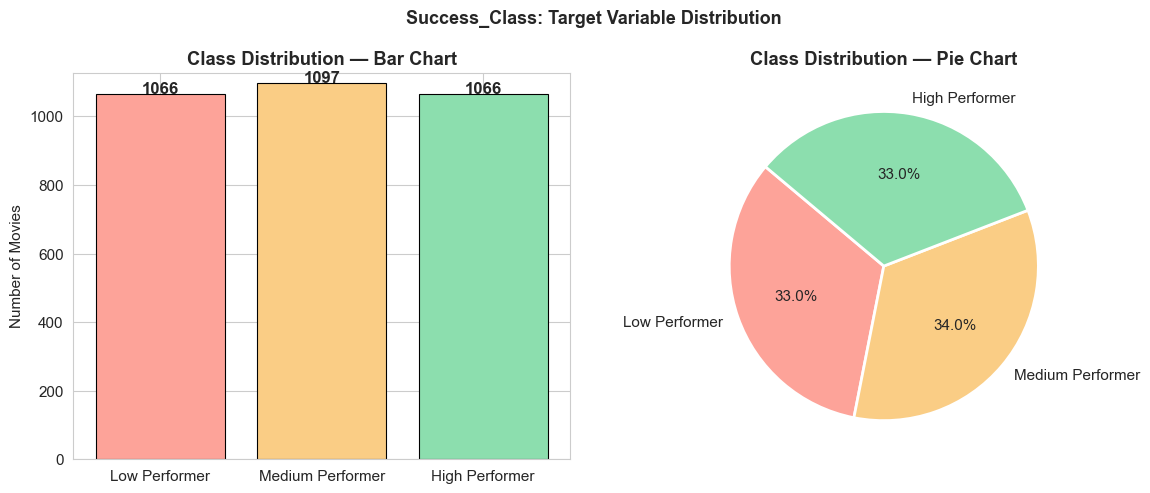

In [ ]:
# Class Distribution Plot 
order  = ['Low Performer', 'Medium Performer', 'High Performer']
colors = ["#FDA399", "#FACD85", "#8CDEAE"]
counts = [movies['Success_Class'].value_counts()[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(order, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution — Bar Chart', fontweight='bold')
axes[0].set_ylabel('Number of Movies')
axes[0].set_ylim(0, max(counts) + 30)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)

# Pie chart
axes[1].pie(counts, labels=order, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution — Pie Chart', fontweight='bold')

plt.suptitle('Success_Class: Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation:
The class distribution is nearly balanced across Low, Medium, and High Performer categories, with each class having approximately one-third of the data. This balanced distribution helps ensure unbiased model training and fair evaluation across all classes.


##  Encoding Categorical Columns and Scaling Numerical Features

In [ ]:
#  Encode Categorical Columns 
print("Unique genres before encoding:", movies['primary_genre'].nunique())

le_genre = LabelEncoder()
le_tgt   = LabelEncoder()

movies['genre_enc'] = le_genre.fit_transform(movies['primary_genre'].fillna('Unknown'))
movies['Target']    = le_tgt.fit_transform(movies['Success_Class'])

print("Target Label Mapping:")
for i, cls in enumerate(le_tgt.classes_):
    print(f"  {i}  →  {cls}")

Unique genres before encoding: 20
Target Label Mapping:
  0  →  High Performer
  1  →  Low Performer
  2  →  Medium Performer


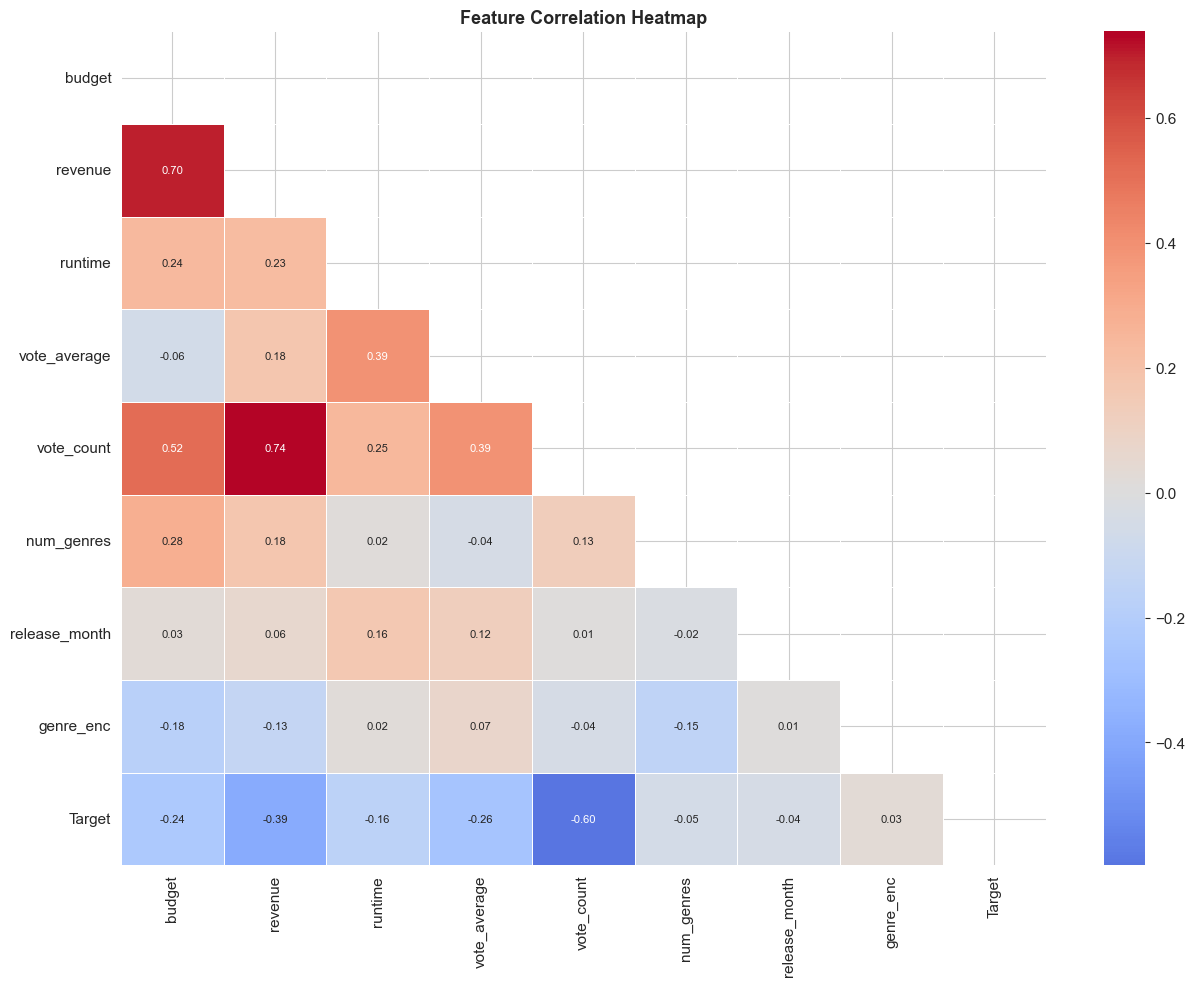

In [51]:
#  Correlation Heatmap 

feat_for_corr = [
    'budget', 'revenue', 'runtime', 'vote_average', 'vote_count','num_genres',
    'release_month', 'genre_enc', 'Target'
]

corr_matrix = movies[feat_for_corr].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Observation:
Categorical variables were successfully encoded into numerical form, making them suitable for machine learning models. The correlation heatmap shows that features like vote_count, revenue, and popularity have stronger relationships with the target, while variables like release_month and genre have weaker influence.

In [55]:
# Prepare Feature Matrix and Target Vector 

feature_columns = [
    'budget',
    'revenue',
    'runtime',
    'vote_average',
    'vote_count',
    'num_genres',
    'release_month',
    'genre_enc'
]

X = movies[feature_columns].copy()
y = movies['Target'].copy()

print(f"Feature matrix (X) shape : {X.shape}")
print(f"Target vector (y) shape  : {y.shape}")
print("\nFeatures used (leakage-free):")
for col in feature_columns:
    print("  -", col)
print("\nFeatures EXCLUDED (used to build target only):")
print("  - roi, weighted_rating, pop_score")

Feature matrix (X) shape : (3229, 8)
Target vector (y) shape  : (3229,)

Features used (leakage-free):
  - budget
  - revenue
  - runtime
  - vote_average
  - vote_count
  - num_genres
  - release_month
  - genre_enc

Features EXCLUDED (used to build target only):
  - roi, weighted_rating, pop_score



## Section 8 — Train-Test Split

In [ ]:
# Stratified Train-Test Split + Scaling 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y      # same class proportions in both sets
)

# Scale AFTER splitting — fit only on training data
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit + transform training data
X_test_s  = scaler.transform(X_test)        # only transform test data (no fitting)

print(f"Training set size : {X_train_s.shape[0]} movies")
print(f"Test set size     : {X_test_s.shape[0]} movies")
print()

class_names = le_tgt.classes_
print("Class distribution — Training:")
for i, cls in enumerate(class_names):
    print(f"  {cls:20s}: {(y_train == i).sum()}")
print()
print("Class distribution — Test:")
for i, cls in enumerate(class_names):
    print(f"  {cls:20s}: {(y_test == i).sum()}")

Training set size : 2583 movies
Test set size     : 646 movies

Class distribution — Training:
  High Performer      : 853
  Low Performer       : 853
  Medium Performer    : 877

Class distribution — Test:
  High Performer      : 213
  Low Performer       : 213
  Medium Performer    : 220


### Observation:
The dataset was split using stratification, ensuring equal class distribution in both training and test sets. Feature scaling was applied correctly after splitting, preventing data leakage and making the data suitable for model training.


##  Model Selection and Hyperparameter Tuning



In [25]:
from sklearn.model_selection import GridSearchCV

In [27]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [52]:

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 0.5, 1, 5, 10],
        "max_iter": [500, 1000]
    },

    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10]
    },

    "Random Forest": {
        "n_estimators": [50, 100, 150],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 2, 4]
    }
}

base_models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

tuned_models = {}

print("GridSearchCV Results:")
for name in base_models:
    grid = GridSearchCV(
        base_models[name],
        param_grids[name],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )
    grid.fit(X_train_s, y_train)
    tuned_models[name] = grid.best_estimator_

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Macro F1:", round(grid.best_score_, 4))

models = tuned_models

GridSearchCV Results:

Logistic Regression
Best Params: {'C': 5, 'max_iter': 500}
Best CV Macro F1: 0.978

Decision Tree
Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV Macro F1: 0.9582

Random Forest
Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV Macro F1: 0.9633


### Model Justification
Logistic Regression was selected as a baseline model because it is simple, fast, and works well when relationships are approximately linear. It also provides interpretable coefficients.

Decision Tree was chosen because it can capture non-linear relationships and is easy to interpret through rule-based splits.

Random Forest was selected as an ensemble method that reduces overfitting and improves generalisation by combining multiple decision trees.


## Model Evaluation and Metrics


In [ ]:
# Train All 3 Models and Evaluate on Test Set
results     = {}
class_names = le_tgt.classes_

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Macro':>10}")
print("─" * 70)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results[name] = {
        'Accuracy' : acc,
        'Precision': prec,
        'Recall'   : rec,
        'F1 Macro' : f1,
        'y_pred'   : y_pred
    }
    print(f"  {name:<23} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")

print()
print("All 3 models evaluated on the held-out test set.")

Model                       Accuracy  Precision     Recall   F1 Macro
──────────────────────────────────────────────────────────────────────
  Logistic Regression         0.9845     0.9845     0.9847     0.9845
  Decision Tree               0.9551     0.9553     0.9556     0.9552
  Random Forest               0.9551     0.9558     0.9552     0.9555

All 3 models evaluated on the held-out test set.


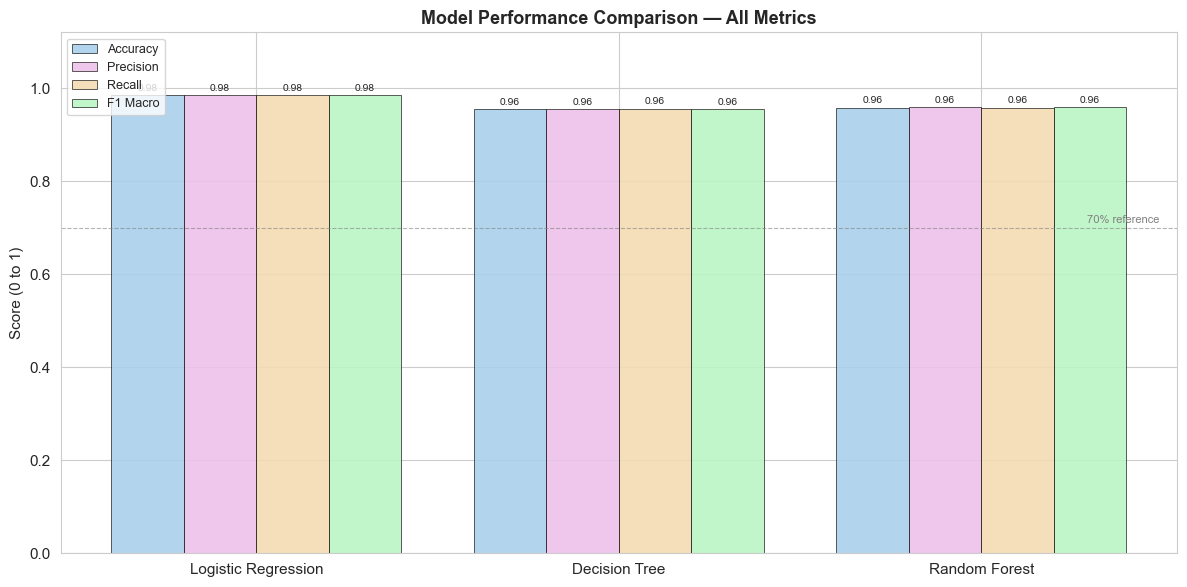

In [ ]:
# Model Comparison Bar Chart 
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
model_names  = list(results.keys())
bar_colors   = ["#A8D0EB", "#EDC0EA", "#F4DAB1", "#B9F5C3"]

x     = np.arange(len(model_names))
width = 0.20

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics_list):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(x + i * width, vals, width,
                  label=metric, color=bar_colors[i],
                  edgecolor='black', linewidth=0.5, alpha=0.88)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score (0 to 1)')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(0.70, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(ax.get_xlim()[1]-0.05, 0.71, '70% reference', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

In [ ]:
# Select Best Model
best_name  = max(results, key=lambda k: results[k]['F1 Macro'])
best_preds = results[best_name]['y_pred']
best_f1    = results[best_name]['F1 Macro']
best_acc   = results[best_name]['Accuracy']

print("=" * 50)
print(f"  BEST MODEL    : {best_name}")
print(f"  Accuracy      : {best_acc:.4f}")
print(f"  F1 (Macro)    : {best_f1:.4f}")
print("=" * 50)

  BEST MODEL    : Logistic Regression
  Accuracy      : 0.9845
  F1 (Macro)    : 0.9845


### Observation

All three models perform very well with high accuracy and F1-scores, indicating that the dataset is well-structured and informative. Among them, Logistic Regression achieved the highest F1-score (~0.9845), making it the best-performing model.

In [ ]:
# Detailed Classification Report (Best Model) 
print(f"Classification Report — {best_name}")
print("=" * 60)
print(classification_report(y_test, best_preds, target_names=class_names))

Classification Report — Logistic Regression
                  precision    recall  f1-score   support

  High Performer       0.98      1.00      0.99       213
   Low Performer       0.98      0.99      0.99       213
Medium Performer       0.99      0.96      0.98       220

        accuracy                           0.98       646
       macro avg       0.98      0.98      0.98       646
    weighted avg       0.98      0.98      0.98       646



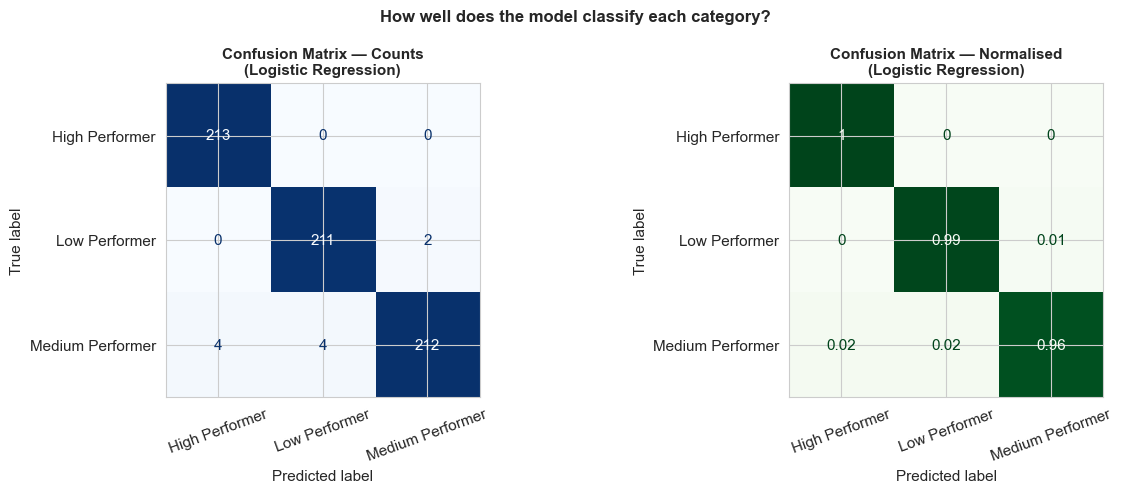

Reading the matrix: Rows = Actual class, Columns = Predicted class
Diagonal = correct predictions.  Off-diagonal = errors.


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — Counts\n({best_name})',
                  fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', labelrotation=20)

# Normalised confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm.round(2), display_labels=class_names)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix — Normalised\n({best_name})',
                  fontweight='bold', fontsize=11)
axes[1].tick_params(axis='x', labelrotation=20)

plt.suptitle('How well does the model classify each category?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Reading the matrix: Rows = Actual class, Columns = Predicted class")
print("Diagonal = correct predictions.  Off-diagonal = errors.")

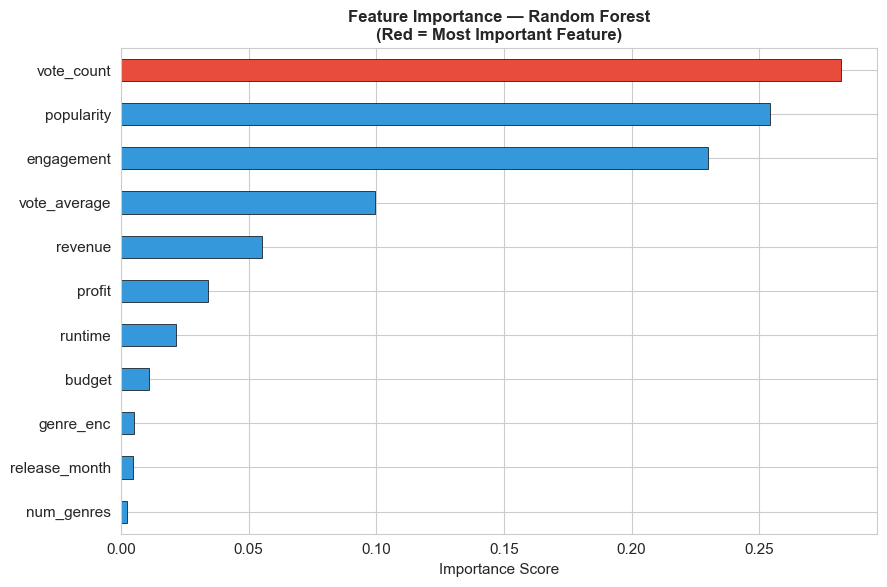

Top 3 most important features:
  vote_count               : 0.2820
  popularity               : 0.2543
  engagement               : 0.2299


In [ ]:
#  Feature Importance (Random Forest)
rf_model = models['Random Forest']

if hasattr(rf_model, 'feature_importances_'):
    fi = pd.Series(rf_model.feature_importances_, index=feature_columns)
    fi = fi.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_fi = ['#E74C3C' if x == fi.max() else '#3498DB' for x in fi.values]
    fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='black', linewidth=0.5)
    ax.set_title('Feature Importance — Random Forest\n(Red = Most Important Feature)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    print("Top 3 most important features:")
    for feat, score in fi.sort_values(ascending=False).head(3).items():
        print(f"  {feat:25s}: {score:.4f}")

### Justification

Feature importance is shown using Random Forest because it provides a reliable and stable importance ranking by averaging across multiple trees. While Decision Tree also provides feature importance, it is less stable due to overfitting. Logistic Regression does not directly provide feature importance but instead gives coefficients, which require different interpretation.


## Final Results, Key Insights, Limitations, and Conclusion

In [ ]:
# Final Results Table 
result_rows = []
for name in results:
    r = results[name]
    result_rows.append({
        'Model'    : name,
        'Accuracy' : round(r['Accuracy'],  4),
        'Precision': round(r['Precision'], 4),
        'Recall'   : round(r['Recall'],    4),
        'F1 Macro' : round(r['F1 Macro'],  4),
    })

final_df = pd.DataFrame(result_rows).sort_values('F1 Macro', ascending=False)
final_df = final_df.reset_index(drop=True)
final_df.index += 1
final_df.index.name = 'Rank'

print("=" * 65)
print("FINAL MODEL COMPARISON TABLE (Sorted by F1 Macro Score)")
print("=" * 65)
print(final_df.to_string())
print()
print(f"Best Model: {final_df.iloc[0]['Model']}")
print(f"  Accuracy  : {final_df.iloc[0]['Accuracy']}")
print(f"  F1 Macro  : {final_df.iloc[0]['F1 Macro']}")

FINAL MODEL COMPARISON TABLE (Sorted by F1 Macro Score)
                    Model  Accuracy  Precision  Recall  F1 Macro
Rank                                                            
1     Logistic Regression    0.9845     0.9845  0.9847    0.9845
2           Random Forest    0.9582     0.9594  0.9582    0.9586
3           Decision Tree    0.9551     0.9553  0.9556    0.9552

Best Model: Logistic Regression
  Accuracy  : 0.9845
  F1 Macro  : 0.9845
